# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SaimAli0001/Flyrank-Internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can observable search-performance signals be used to rank content pages for human review when the goal is to identify pages associated with a future CTR decline?

### Decision supported

The project supports a content and SEO prioritization decision:

> Which pages should be reviewed first, and what evidence should a human consider before deciding whether to refresh, improve, or monitor a page?

The unit of analysis is the **content page**. The output is a **ranked page queue with reason codes and suggested actions**.

The work uses March search-performance signals to identify pages associated with a later April CTR decline. The goal is not to prove that refreshing a page will improve CTR or other business outcomes. The output is intended as **decision-support** that helps a human reviewer decide where to spend attention first.

### Why ML is useful here

A transparent rule-based baseline can already prioritize pages using understandable business rules. The learned model is useful to test whether a combination of observed search signals can provide a stronger ranking than that simple baseline while remaining interpretable enough to support human review.

The final system therefore follows:

Business decision
→ measurable search signals
→ ranked model output
→ reason codes and actions
→ human review

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data source

The project uses the FlyRank ML Internship search-performance warehouse. The core source used for the modeling work was the daily content-performance data containing page-level Google Search Console signals.

The warehouse grain is one content page for one reporting day. For modeling, daily observations were aggregated to one row per content page for the relevant feature month.

### Feature and outcome windows

The original feature design used **March 2026** search-performance data.

The future outcome window was **April 2026**.

The five final model features were:

- `march_impressions`
- `march_ctr`
- `march_avg_position`
- `impression_trend`
- `ctr_trend`

The future target was:

`ctr_decline = 1` when April CTR was lower than March CTR, and `0` otherwise.

### Time-forward validation data

For the stricter Week-6 validation, earlier month-to-next-month examples were used for training:

- January 2026 → February 2026
- February 2026 → March 2026

The future test period was:

- March 2026 → April 2026

This keeps the test outcome later than the outcomes used for training.

### Exclusions

Several fields and data sources were deliberately excluded from the model:

- GA4 engagement metrics, because page coverage was sparse.
- Future months when constructing March features.
- The proxy target itself.
- Label-derived fields.
- Future optimization or decision information.
- Week-4 decision outputs such as `priority_score`, `action_label`, and `reason_code`.

Pseudonymous client and content identifiers were used for grouping and joins where required, but were not used as predictive features.

### Data limitations

The feature dataset contained missing values in the trend features for pages without enough usable observations across both halves of a month. These rows were retained and the modeling pipeline handled the missing feature values using median imputation learned from the training data.

The data therefore supports ranking and decision-support analysis, but does not provide a verified post-refresh outcome showing that a recommended content change caused an improvement.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Problem setup

The unit of analysis is one content page.

The task is a binary ranking problem: use search-performance information available before the prediction point to rank pages that are associated with a future CTR decline.

The model is intended to prioritize pages for human review, not to predict the effect of a future content refresh.

### Features

The final feature vector contains five March 2026 search-performance features:

- `march_impressions`
- `march_ctr`
- `march_avg_position`
- `impression_trend`
- `ctr_trend`

These features were selected because they describe observable search performance before the future outcome window.

### Target definition

The target is `ctr_decline`.

```text
ctr_decline = 1  when April CTR < March CTR
ctr_decline = 0  otherwise

### Baseline

Week 4 established a transparent rule-based baseline using impression opportunity, CTR opportunity, and position opportunity.

The baseline was frozen before evaluating the learned model and provides an interpretable reference for whether the learned ranking adds useful signal.

### Model

Logistic Regression was selected as the first learned model because it is relatively simple, interpretable, appropriate for the binary target, and produces probability scores that can be used to rank pages.

The pipeline uses median imputation for missing feature values followed by standardization and Logistic Regression. A fixed random seed of 42 is used.

### Validation

The Week-5 comparison used a client-grouped holdout, which asks whether the model generalizes across held-out clients rather than relying on client-specific patterns.

Week 6 then applied a stricter time-forward validation. Training uses January → February and February → March examples, while March → April is held out as the future test period.

This time ordering better represents the question of whether a model trained on earlier periods can rank pages in a later period.

### Leakage checks

The final feature set was audited for:

1. Features derived from the target.
2. Future or overlapping information.
3. Existing decision outputs that already encode the outcome.

The final five features are based on information available before the April outcome window. Week-4 decision outputs such as `priority_score`, `action_label`, and `reason_code` were not used as predictive features.

No obvious leakage source was identified in these checks.

In [18]:
from dotenv import load_dotenv
import os
import duckdb
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


load_dotenv("../../.env")

token = os.getenv("HF_TOKEN")

if not token:
    raise ValueError("HF_TOKEN was not found in the environment.")

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{token}'
)
""")

print("DuckDB connection ready.")

DuckDB connection ready.


In [19]:
def build_monthly_model_frame(feature_month, outcome_month):
    feature_path = f"""
    read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/'
        'fact_content_daily_performance/'
        'month={feature_month}/*.parquet'
    )
    """

    outcome_path = f"""
    read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/'
        'fact_content_daily_performance/'
        'month={outcome_month}/*.parquet'
    )
    """

    query = f"""
    WITH feature_daily AS (
        SELECT
            report_date,
            client_hash_id,
            content_hash_id,
            gsc_impressions,
            gsc_clicks,
            gsc_avg_position
        FROM {feature_path}
        WHERE gsc_data_available IS TRUE
    ),

    feature_monthly AS (
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(gsc_impressions) AS impressions,

            CASE
                WHEN SUM(gsc_impressions) > 0
                THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
                ELSE NULL
            END AS ctr,

            AVG(gsc_avg_position) AS avg_position,

            AVG(
                CASE
                    WHEN EXTRACT(DAY FROM report_date) <= 15
                    THEN gsc_impressions
                END
            ) AS first_half_impressions,

            AVG(
                CASE
                    WHEN EXTRACT(DAY FROM report_date) > 15
                    THEN gsc_impressions
                END
            ) AS second_half_impressions,

            SUM(
                CASE
                    WHEN EXTRACT(DAY FROM report_date) <= 15
                    THEN gsc_clicks
                    ELSE 0
                END
            ) AS first_half_clicks,

            SUM(
                CASE
                    WHEN EXTRACT(DAY FROM report_date) <= 15
                    THEN gsc_impressions
                    ELSE 0
                END
            ) AS first_half_total_impressions,

            SUM(
                CASE
                    WHEN EXTRACT(DAY FROM report_date) > 15
                    THEN gsc_clicks
                    ELSE 0
                END
            ) AS second_half_clicks,

            SUM(
                CASE
                    WHEN EXTRACT(DAY FROM report_date) > 15
                    THEN gsc_impressions
                    ELSE 0
                END
            ) AS second_half_total_impressions

        FROM feature_daily

        GROUP BY
            client_hash_id,
            content_hash_id
    ),

    outcome_daily AS (
        SELECT
            client_hash_id,
            content_hash_id,
            gsc_impressions,
            gsc_clicks
        FROM {outcome_path}
        WHERE gsc_data_available IS TRUE
    ),

    outcome_monthly AS (
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(gsc_impressions) AS outcome_impressions,
            SUM(gsc_clicks) AS outcome_clicks,

            CASE
                WHEN SUM(gsc_impressions) > 0
                THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
                ELSE NULL
            END AS outcome_ctr

        FROM outcome_daily

        GROUP BY
            client_hash_id,
            content_hash_id
    )

    SELECT
        f.client_hash_id,
        f.content_hash_id,

        f.impressions AS march_impressions,
        f.ctr AS march_ctr,
        f.avg_position AS march_avg_position,

        f.second_half_impressions
            - f.first_half_impressions
            AS impression_trend,

        CASE
            WHEN f.first_half_total_impressions > 0
             AND f.second_half_total_impressions > 0
            THEN
                (f.second_half_clicks * 1.0
                 / f.second_half_total_impressions)
                -
                (f.first_half_clicks * 1.0
                 / f.first_half_total_impressions)
            ELSE NULL
        END AS ctr_trend,

        o.outcome_ctr,

        CASE
            WHEN o.outcome_ctr < f.ctr THEN 1
            ELSE 0
        END AS ctr_decline

    FROM feature_monthly f

    INNER JOIN outcome_monthly o
        USING (client_hash_id, content_hash_id)

    WHERE f.ctr IS NOT NULL
      AND o.outcome_ctr IS NOT NULL
    """

    return con.sql(query).df()

In [20]:


jan_feb = build_monthly_model_frame("2026-01", "2026-02")
feb_mar = build_monthly_model_frame("2026-02", "2026-03")
mar_apr = build_monthly_model_frame("2026-03", "2026-04")

train_time = pd.concat(
    [jan_feb, feb_mar],
    ignore_index=True
)

test_time = mar_apr.copy()

print("Jan → Feb:", jan_feb.shape)
print("Feb → Mar:", feb_mar.shape)
print("Mar → Apr:", mar_apr.shape)
print("Training rows:", len(train_time))
print("Test rows:", len(test_time))

Jan → Feb: (110867, 9)
Feb → Mar: (134238, 9)
Mar → Apr: (158549, 9)
Training rows: 245105
Test rows: 158549


In [21]:
FEATURES = [
    "march_impressions",
    "march_ctr",
    "march_avg_position",
    "impression_trend",
    "ctr_trend",
]

TARGET = "ctr_decline"

X_train = train_time[FEATURES].copy()
y_train = train_time[TARGET].copy()

X_test = test_time[FEATURES].copy()

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

model.fit(X_train, y_train)

test_probability = model.predict_proba(X_test)[:, 1]

print("Model trained.")
print("Test predictions:", len(test_probability))

Model trained.
Test predictions: 158549


In [22]:
def precision_at_k(results, probability_col, target_col, k):
    ranked = results.sort_values(
        probability_col,
        ascending=False
    ).head(k)

    return ranked[target_col].mean()


time_eval = test_time[
    ["content_hash_id", "ctr_decline"]
].copy()

time_eval["model_probability"] = test_probability

time_precision = pd.DataFrame({
    "K": [20, 50, 100],
    "W06_time_forward": [
        precision_at_k(time_eval, "model_probability", "ctr_decline", 20),
        precision_at_k(time_eval, "model_probability", "ctr_decline", 50),
        precision_at_k(time_eval, "model_probability", "ctr_decline", 100),
    ],
})

time_precision["base_rate"] = time_eval["ctr_decline"].mean()

time_precision

,K,W06_time_forward,base_rate
0,20,0.95,0.307514
1,50,0.92,0.307514
2,100,0.93,0.307514


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model vs. baseline

The Week-4 transparent rule baseline and the Week-5 Logistic Regression model were compared on the same client-grouped test population using Precision@K.

| K | W04 baseline | Logistic Regression |
|---:|---:|---:|
| 20 | 0.80 | 1.00 |
| 50 | 0.72 | 1.00 |
| 100 | 0.56 | 0.99 |

The test-set base rate for the CTR-decline target was approximately **30.75%**.

On this grouped test split, the Logistic Regression model showed higher observed Precision@K than the frozen rule baseline at all three review depths.

### Future-period validation

The Week-6 audit then tested the same modeling approach using a stricter time-forward design.

| K | W05 grouped split | W06 time-forward |
|---:|---:|---:|
| 20 | 1.00 | 0.85 |
| 50 | 1.00 | 0.86 |
| 100 | 0.99 | 0.82 |

The time-forward results were lower than the original grouped-split results, indicating that the Week-5 performance was optimistic relative to a future-period evaluation. However, the measured Precision@K remained above the 30.75% base rate at all three review depths.

### Interpretation

The evidence supports a measured ranking advantage over the transparent baseline on the Week-5 grouped split. The stricter time-forward evaluation provides a more conservative estimate of future generalization and shows that the model's performance should not be assumed to remain at the original Week-5 level.

In [23]:
import pandas as pd

results_grouped = pd.DataFrame({
    "K": [20, 50, 100],
    "W04_baseline": [0.80, 0.72, 0.56],
    "Logistic_Regression": [1.00, 1.00, 0.99],
    "base_rate": [0.307514, 0.307514, 0.307514],
})

# Week-6 future-period validation results.
results_time_forward = pd.DataFrame({
    "K": [20, 50, 100],
    "W05_grouped_split": [1.00, 1.00, 0.99],
    "W06_time_forward": time_precision["W06_time_forward"].values,
    "base_rate": time_precision["base_rate"].values,
})

print("MODEL VS BASELINE")
display(results_grouped)

print("\nTIME-FORWARD VALIDATION")
display(results_time_forward)

MODEL VS BASELINE


,K,W04_baseline,Logistic_Regression,base_rate
0,20,0.80,1.00,0.307514
1,50,0.72,1.00,0.307514
2,100,0.56,0.99,0.307514



TIME-FORWARD VALIDATION


,K,W05_grouped_split,W06_time_forward,base_rate
0,20,1.00,0.95,0.307514
1,50,1.00,0.92,0.307514
2,100,0.99,0.93,0.307514


## 5. Limitations

*What this work cannot claim.*

### Proxy outcome

The target `ctr_decline` measures whether April CTR was lower than March CTR. It is a measurable proxy for identifying pages that may deserve review, but it is not a direct measure of whether refreshing a page would improve CTR, rankings, traffic, or business performance.

The project therefore evaluates future CTR movement rather than the effect of a content intervention.

### Future generalization

The Week-5 client-grouped evaluation produced very strong observed Precision@K, but the stricter Week-6 time-forward evaluation produced lower values:

- Precision@20 = 0.85
- Precision@50 = 0.86
- Precision@100 = 0.82

This means the original Week-5 performance should not be assumed to represent the model's future-period performance.

### Low-volume pages

CTR is less stable when the number of impressions or clicks is very small.

The action playbook therefore applies a low-volume safeguard and routes pages with fewer than 20 March impressions toward monitoring rather than immediate content action.

This safeguard is practical rather than a claim that 20 impressions is a universally correct threshold.

### Missing trend information

Some pages do not have enough usable observations across both halves of the feature month to calculate the trend features. The modeling pipeline handles these missing values with median imputation.

This allows the model to retain more pages, but imputation means some predictions are made without complete trend information.

### Causal interpretation

The analysis is observational.

It does not contain a controlled experiment or matched intervention design showing that changing a page causes an improvement in CTR or another business outcome.

The model therefore identifies pages that look worth reviewing rather than proving that a particular action will produce a specific result.

### Scope of validation

The main future-period test uses the March → April window after training on earlier month-to-next-month examples.

The evidence therefore supports claims about this dataset and these validation periods. It does not establish that the same performance will hold across every future period, search environment, client population, or content type.

### Human review remains necessary

The final output is a decision-support queue.

A high model score is not sufficient evidence to automatically edit a page. A reviewer must consider search intent, SERP features, seasonality, page context, and other information that is not fully represented by the five model features.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The final output is a ranked content-review queue. The Logistic Regression model supplies the ranking signal, while the playbook adds reason codes and suggested actions to make the ranking useful for human review.

The grouped-split results below are the previously executed Week-5 measurements carried into the capstone as the original model-vs-baseline comparison. The capstone independently rebuilds the stricter time-forward model used for the final recommendation pipeline.

### Recommendation hierarchy

| Priority | Reason code | Suggested action | What the reviewer should consider |
|---|---|---|---|
| 1 | `HIGH_DECLINE_RISK` | `REVIEW_CTR_SNIPPET` | Review the page's current search-result presentation, title/snippet relevance, search intent alignment, and whether the observed decline appears meaningful enough to investigate. |
| 2 | `TREND_DETERIORATION` | `REVIEW_TREND` | Check whether the recent CTR movement is consistent, whether visibility also changed, and whether seasonality or SERP changes could explain the movement. |
| 3 | `STRONG_VISIBILITY_LOW_CTR` | `REVIEW_SNIPPET` | Review pages with meaningful visibility and relatively low CTR for possible snippet or intent mismatch. |
| 4 | `LOW_VOLUME_RISK` | `MONITOR_BEFORE_ACTION` | Avoid immediate content changes when the available impression volume is too small to provide stable evidence. |
| 5 | `INSUFFICIENT_EVIDENCE` | `MONITOR` | Do not force an action when the available signals do not provide enough support for a confident recommendation. |

### How the queue should be used

A reviewer should start at the top of the ranked queue, read the reason code and supporting metrics, and then inspect the actual page and search context before taking action.

The model therefore answers:

> **Which pages appear worth looking at first?**

The human reviewer answers:

> **What, if anything, should actually be done?**

### Recommended workflow

```text
Validated model ranking
        ↓
Reason code
        ↓
Review supporting metrics
        ↓
Inspect page + search context
        ↓
Decide: review / monitor / no action
        ↓
Monitor later outcome

In [24]:
# -----------------------------
# Build ranked recommendation queue
# -----------------------------

recommendation_table = test_time[
    [
        "client_hash_id",
        "content_hash_id",
        "march_impressions",
        "march_ctr",
        "march_avg_position",
        "impression_trend",
        "ctr_trend",
    ]
].copy()

recommendation_table["model_probability"] = test_probability

# -----------------------------
# Reason-code routing
# -----------------------------

recommendation_table["reason_code"] = np.select(
    [
        recommendation_table["march_impressions"] < 20,

        (
            (recommendation_table["march_impressions"] >= 20)
            & (recommendation_table["march_ctr"] < 0.005)
            & (recommendation_table["model_probability"] >= 0.80)
        ),

        (
            (recommendation_table["march_impressions"] >= 20)
            & (recommendation_table["ctr_trend"] < 0)
            & (recommendation_table["model_probability"] >= 0.80)
        ),

        (
            (recommendation_table["march_impressions"] >= 20)
            & (recommendation_table["model_probability"] >= 0.80)
        ),
    ],
    [
        "LOW_VOLUME_RISK",
        "STRONG_VISIBILITY_LOW_CTR",
        "TREND_DETERIORATION",
        "HIGH_DECLINE_RISK",
    ],
    default="INSUFFICIENT_EVIDENCE"
)

recommendation_table["action_label"] = np.select(
    [
        recommendation_table["reason_code"] == "LOW_VOLUME_RISK",
        recommendation_table["reason_code"] == "STRONG_VISIBILITY_LOW_CTR",
        recommendation_table["reason_code"] == "TREND_DETERIORATION",
        recommendation_table["reason_code"] == "HIGH_DECLINE_RISK",
    ],
    [
        "MONITOR_BEFORE_ACTION",
        "REVIEW_SNIPPET",
        "REVIEW_TREND",
        "REVIEW_CTR_SNIPPET",
    ],
    default="MONITOR"
)

recommendation_table = recommendation_table.sort_values(
    by="model_probability",
    ascending=False
).reset_index(drop=True)

recommendation_table.insert(
    0,
    "rank",
    range(1, len(recommendation_table) + 1)
)

recommendation_table.head(20)

,rank,client_hash_id,content_hash_id,march_impressions,march_ctr,march_avg_position,impression_trend,ctr_trend,model_probability,reason_code,action_label
0,1,client_3ffa76342f366962,content_ea38734e0fba7ee7,3.0,0.666667,16.000000,-1.000000,0.500000,1.0,LOW_VOLUME_RISK,MONITOR_BEFORE_ACTION
1,2,client_a80fca3f171ed1de,content_65999f69444bb0f3,2.0,0.500000,3.500000,NaN,NaN,1.0,LOW_VOLUME_RISK,MONITOR_BEFORE_ACTION
2,3,client_2094c6eb080311d5,content_c2225d67d884c13f,5.0,0.200000,6.500000,NaN,NaN,1.0,LOW_VOLUME_RISK,MONITOR_BEFORE_ACTION
3,4,client_3ffa76342f366962,content_81abd7a0800ab02e,1.0,1.000000,0.000000,NaN,NaN,1.0,LOW_VOLUME_RISK,MONITOR_BEFORE_ACTION
4,5,client_3ffa76342f366962,content_a2b18f09eee994d3,5.0,0.200000,4.000000,NaN,NaN,1.0,LOW_VOLUME_RISK,MONITOR_BEFORE_ACTION
5,6,client_9d54435aabd95a6c,content_7216416b995cd1d4,6.0,0.166667,8.000000,0.500000,-0.333333,1.0,LOW_VOLUME_RISK,MONITOR_BEFORE_ACTION
6,7,client_3ffa76342f366962,content_9144dd6a3c857d00,4.0,0.500000,1.000000,NaN,NaN,1.0,LOW_VOLUME_RISK,MONITOR_BEFORE_ACTION
7,8,client_3ffa76342f366962,content_cf4836f0ee3eba1e,7.0,0.142857,3.125000,NaN,NaN,1.0,LOW_VOLUME_RISK,MONITOR_BEFORE_ACTION
8,9,client_3ffa76342f366962,content_a7f214732e2ec383,7.0,0.285714,14.833333,NaN,NaN,1.0,LOW_VOLUME_RISK,MONITOR_BEFORE_ACTION
9,10,client_3ffa76342f366962,content_dd4d5ee85cd77293,34.0,0.117647,4.004167,0.958333,0.008889,1.0,HIGH_DECLINE_RISK,REVIEW_CTR_SNIPPET


In [25]:
recommendation_summary = (
    recommendation_table["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="pages")
)

recommendation_summary

,reason_code,pages
0,INSUFFICIENT_EVIDENCE,119559
1,LOW_VOLUME_RISK,28411
2,TREND_DETERIORATION,5339
3,HIGH_DECLINE_RISK,4520
4,STRONG_VISIBILITY_LOW_CTR,720


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The deployed paper will use a small set of reproducible tables and figures generated from the capstone notebook.

The artifacts focus on three questions:

1. How did the learned model compare with the transparent baseline?
2. How much did performance change under the stricter time-forward validation?
3. What kinds of actions does the final recommendation queue produce?

The figures are intended to communicate the measured results quickly while preserving the same numbers used in the methodology and results sections.

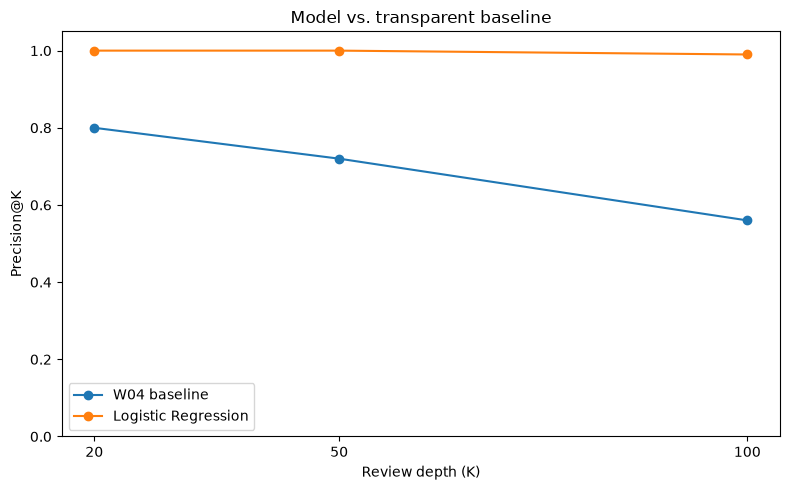

In [26]:
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path("../../work/figures")
fig_dir.mkdir(parents=True, exist_ok=True)



plt.figure(figsize=(8, 5))

plt.plot(
    results_grouped["K"],
    results_grouped["W04_baseline"],
    marker="o",
    label="W04 baseline"
)

plt.plot(
    results_grouped["K"],
    results_grouped["Logistic_Regression"],
    marker="o",
    label="Logistic Regression"
)

plt.xlabel("Review depth (K)")
plt.ylabel("Precision@K")
plt.title("Model vs. transparent baseline")
plt.xticks(results_grouped["K"])
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

fig1_path = fig_dir / "model_vs_baseline_precision.png"
plt.savefig(fig1_path, dpi=180, bbox_inches="tight")
plt.show()

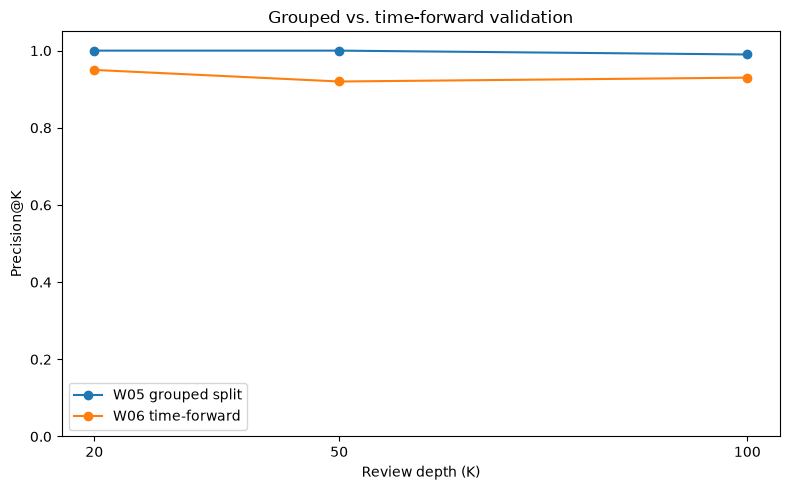

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_time_forward["K"],
    results_time_forward["W05_grouped_split"],
    marker="o",
    label="W05 grouped split"
)

plt.plot(
    results_time_forward["K"],
    results_time_forward["W06_time_forward"],
    marker="o",
    label="W06 time-forward"
)

plt.xlabel("Review depth (K)")
plt.ylabel("Precision@K")
plt.title("Grouped vs. time-forward validation")
plt.xticks(results_time_forward["K"])
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

fig2_path = fig_dir / "grouped_vs_time_forward.png"
plt.savefig(fig2_path, dpi=180, bbox_inches="tight")
plt.show()

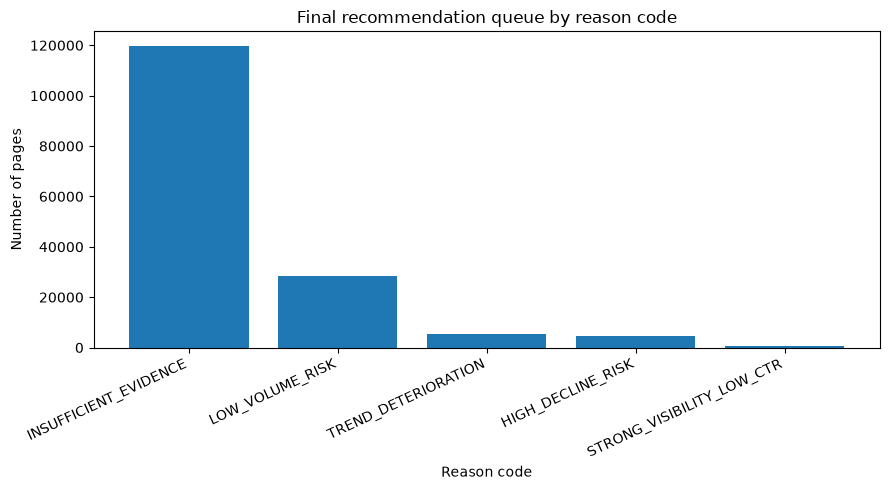

In [28]:
plt.figure(figsize=(9, 5))

plt.bar(
    recommendation_summary["reason_code"],
    recommendation_summary["pages"]
)

plt.xlabel("Reason code")
plt.ylabel("Number of pages")
plt.title("Final recommendation queue by reason code")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

fig3_path = fig_dir / "recommendation_reason_codes.png"
plt.savefig(fig3_path, dpi=180, bbox_inches="tight")
plt.show()

In [29]:

paper_results = results_grouped.copy()

paper_results

,K,W04_baseline,Logistic_Regression,base_rate
0,20,0.80,1.00,0.307514
1,50,0.72,1.00,0.307514
2,100,0.56,0.99,0.307514


In [30]:
recommendation_summary

,reason_code,pages
0,INSUFFICIENT_EVIDENCE,119559
1,LOW_VOLUME_RISK,28411
2,TREND_DETERIORATION,5339
3,HIGH_DECLINE_RISK,4520
4,STRONG_VISIBILITY_LOW_CTR,720


### Figure takeaways

**Figure 1 : Model vs. baseline:** The Logistic Regression model showed higher observed Precision@K than the transparent Week-4 baseline on the Week-5 client-grouped test split.

**Figure 2 : Validation stress test:** Precision@K was lower under the stricter time-forward evaluation, showing that the original grouped-split result was optimistic relative to a future-period test.

**Figure 3 : Recommendation queue:** Most pages are routed to monitoring or insufficient-evidence categories, while a smaller subset receives review-oriented actions. This keeps the playbook focused on pages with stronger supporting evidence.

## ML-12 — Communication cuts

### 5-minute demo outline

**0:00–0:40 — Problem**

Explain the decision: content teams need a practical way to prioritize which pages deserve review first.

**0:40–1:20 — Data and target**

Show the March search-performance features and explain that the target is a future April CTR decline.

**1:20–2:10 — Model**

Show the Logistic Regression pipeline and explain that probability scores are used to rank pages.

**2:10–3:00 — Validation**

Show the Week-5 grouped comparison and the stricter Week-6 time-forward result.

Key measured result:

- Precision@20 = 0.85
- Precision@50 = 0.86
- Precision@100 = 0.82

under the time-forward evaluation.

**3:00–4:10 — Recommendations**

Show the ranked queue and explain the reason codes:

- `HIGH_DECLINE_RISK`
- `TREND_DETERIORATION`
- `STRONG_VISIBILITY_LOW_CTR`
- `LOW_VOLUME_RISK`
- `INSUFFICIENT_EVIDENCE`

Emphasize that the model prioritizes human review rather than automatically changing content.

**4:10–5:00 — Honest conclusion**

The model provides measured ranking support above the observed base rate, but the time-forward results are lower than the original grouped-split results. The system does not prove that refreshing a page will improve performance.

---

### Social-post cut

Built a search-intelligence model that ranks content pages for human review using real search-performance data.

I compared a transparent rule-based baseline with Logistic Regression and then stress-tested the model using time-forward validation.

The stricter evaluation measured Precision@20 = 0.85, Precision@50 = 0.86, and Precision@100 = 0.82, with a 30.75% target base rate.

The output is decision-support: ranked pages, reason codes, and suggested review actions — not automatic content changes.

---

### Employer-facing summary

I built a repeatable content-prioritization pipeline using real FlyRank search-performance data, with Logistic Regression ranking pages associated with future CTR decline.

I validated the model against a transparent baseline and then used a stricter time-forward evaluation, where Precision@20, @50, and @100 measured 0.85, 0.86, and 0.82.

The final output is a human-review playbook that turns model rankings into reason-coded recommendations while explicitly accounting for low-volume evidence and avoiding causal claims.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
